In [48]:
# import libraries and data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

data = pd.read_csv("combined_data.csv")

In [42]:
# input output labels
X = data["text_without_emoji"].tolist()
y = data["emoji_label"].tolist()

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

# encode emojis as integers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# should be 43 classes
num_classes = len(le.classes_)
print("Number of emoji classes:", num_classes)

vectorizer = TfidfVectorizer(
    max_features=5000,  # limit vocabulary to top 5000 meaningful phrases
    ngram_range=(1, 2)  # 1 to 2 word phrases
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# train the model to predict emoji
lr = LogisticRegression(
    max_iter=200
)
lr.fit(X_train_tfidf, y_train_enc)
# predict emoji
y_pred = lr.predict(X_test_tfidf)

accuracy = accuracy_score(y_test_enc, y_pred)
print("Accuracy:", accuracy)

# show metrics
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Number of emoji classes: 43
Accuracy: 0.2011510624073482

Classification Report:
                               precision    recall  f1-score   support

backhand_index_pointing_right       0.31      0.54      0.40      4044
                   check_mark       0.30      0.30      0.30      4049
            check_mark_button       0.33      0.37      0.35      4078
                   clown_face       0.19      0.21      0.20      3989
                      cooking       0.42      0.28      0.34      3966
                          egg       0.39      0.39      0.39      4022
                 enraged_face       0.17      0.22      0.19      3994
                         eyes       0.13      0.15      0.14      3913
      face_holding_back_tears       0.14      0.18      0.15      3968
           face_savoring_food       0.22      0.23      0.23      4014
    face_with_steam_from_nose       0.11      0.10      0.10      3998
       face_with_tears_of_joy       0.18      0.16      0.17      

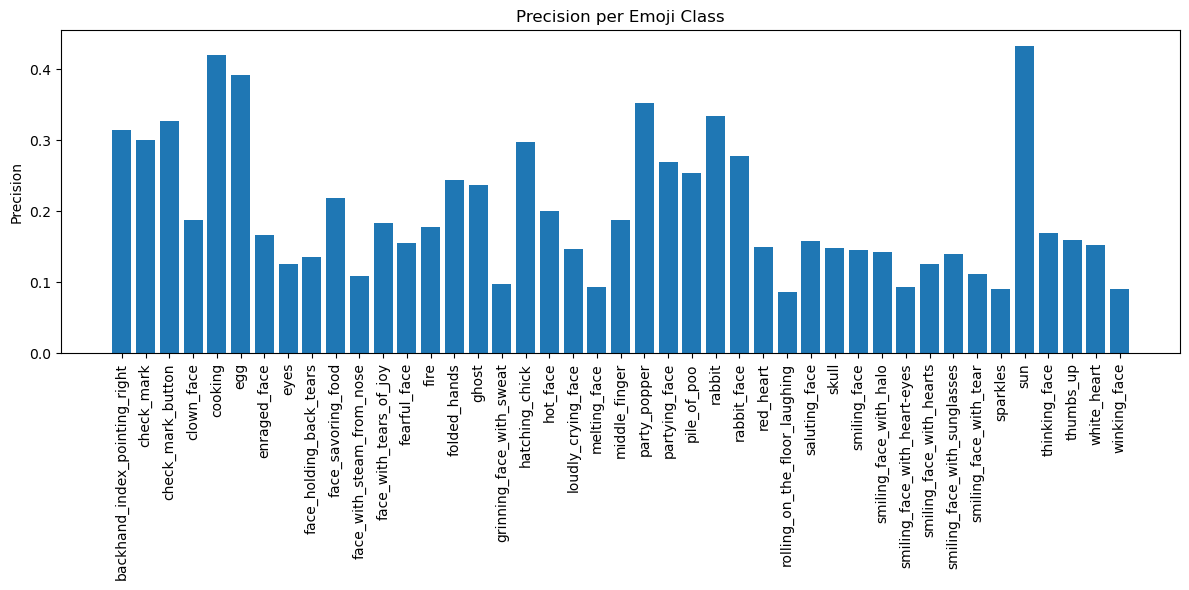

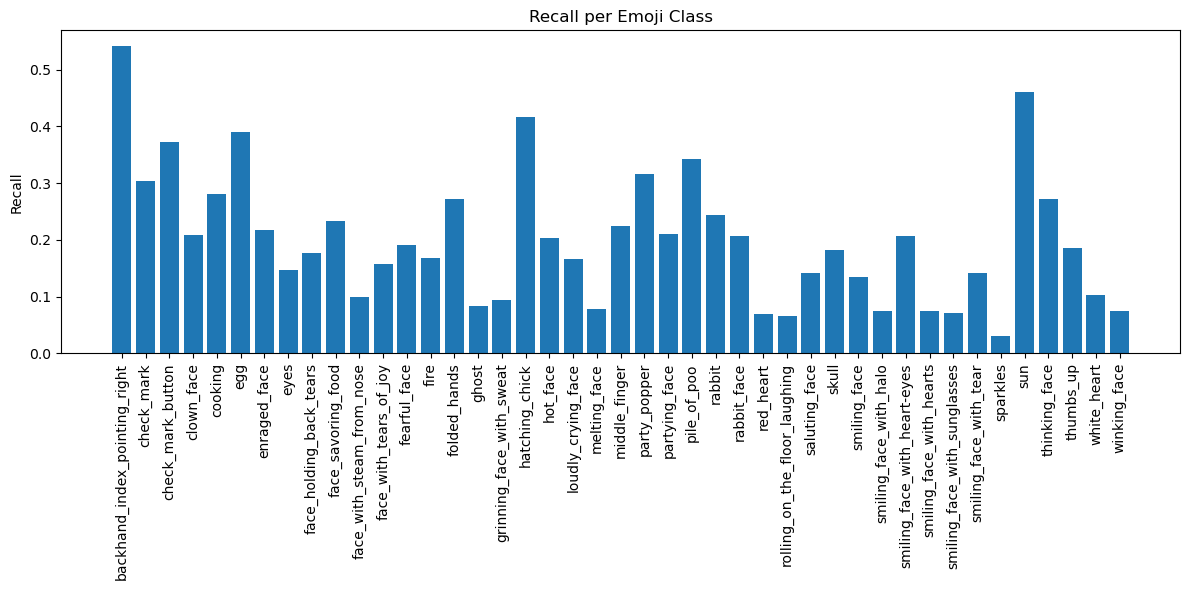

In [57]:
import matplotlib.pyplot as plt

# make precision graph
precisions = precision_score(y_test_enc, y_pred, average=None)

plt.figure(figsize=(12, 6))
plt.bar(le.classes_, precisions)
plt.xticks(rotation=90)
plt.ylabel("Precision")
plt.title("Precision per Emoji Class")
plt.tight_layout()
plt.show()

# make recall graph
recalls = recall_score(y_test_enc, y_pred, average=None)

plt.figure(figsize=(12, 6))
plt.bar(le.classes_, recalls)
plt.xticks(rotation=90)
plt.ylabel("Recall")
plt.title("Recall per Emoji Class")
plt.tight_layout()
plt.show()